<a href="https://colab.research.google.com/github/Hniii/Machine-learning/blob/main/Lab2_team2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP : Descente de Gradient - Régression Linéaire
## Introduction
Dans ce TP, nous allons étudier la descente de gradient appliquée à un cas simple de **régression linéaire**.
Nous répondrons aux questions suivantes en détaillant chaque étape et en illustrant nos résultats avec des visualisations.


In [ ]:
# Importation des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from sklearn.linear_model import LinearRegression

## Chargement et visualisation des données

Saving RK_ML_DG_data.csv to RK_ML_DG_data (1).csv
           X          Y
0  32.502345  31.707006
1  53.426804  68.777596
2  61.530358  62.562382
3  47.475640  71.546632
4  59.813208  87.230925


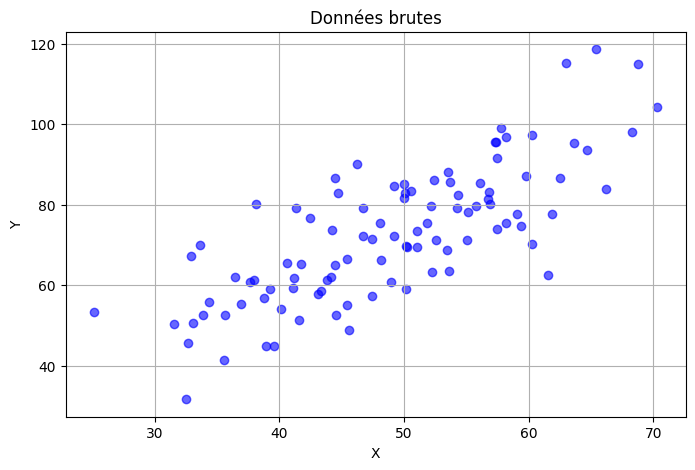

In [ ]:
# Chargement du fichier de données
from google.colab import files
uploaded = files.upload()

# Lecture du fichier CSV
data = pd.read_csv(list(uploaded.keys())[0], header=None)
data.columns = ['X', 'Y']

# Visualisation des premières lignes
print(data.head())

# Extraction des valeurs
X = data['X'].values
Y = data['Y'].values

# Tracé des données
plt.figure(figsize=(8,5))
plt.scatter(X, Y, color='blue', alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Données brutes')
plt.grid()
plt.show()

## Brute Force : Combien de modèles différents ?
Nous allons estimer combien de combinaisons possibles existent pour les paramètres **m** et **b**.


In [ ]:
# Calcul du nombre de modèles
m_values = np.arange(-50, 50, 0.01)
b_values = np.arange(-10, 10, 0.01)

N_m = len(m_values)
N_b = len(b_values)
N_models = N_m * N_b

print(f"Nombre total de modèles possibles : {N_models}")

Nombre total de modèles possibles : 20000000


## Fonction d'erreur MSE

In [ ]:
# Définition de la fonction MSE
def mse(m, b, X, Y):
    predictions = m * X + b
    return np.mean((Y - predictions) ** 2)

print("Fonction MSE implémentée avec succès.")

Fonction MSE implémentée avec succès.


## Recherche du meilleur modèle avec Brute Force

In [ ]:
# Recherche du meilleur modèle (simplifiée pour exécution rapide)
m_values = np.arange(-50, 50, 1)
b_values = np.arange(-10, 10, 1)

best_m, best_b, min_error = 0, 0, float('inf')
for m, b in product(m_values, b_values):
    error = mse(m, b, X, Y)
    if error < min_error:
        min_error = error
        best_m, best_b = m, b

print(f'Modèle optimal trouvé : m = {best_m}, b = {best_b}, MSE = {min_error}')

Modèle optimal trouvé : m = 1, b = 9, MSE = 338.38528631392944


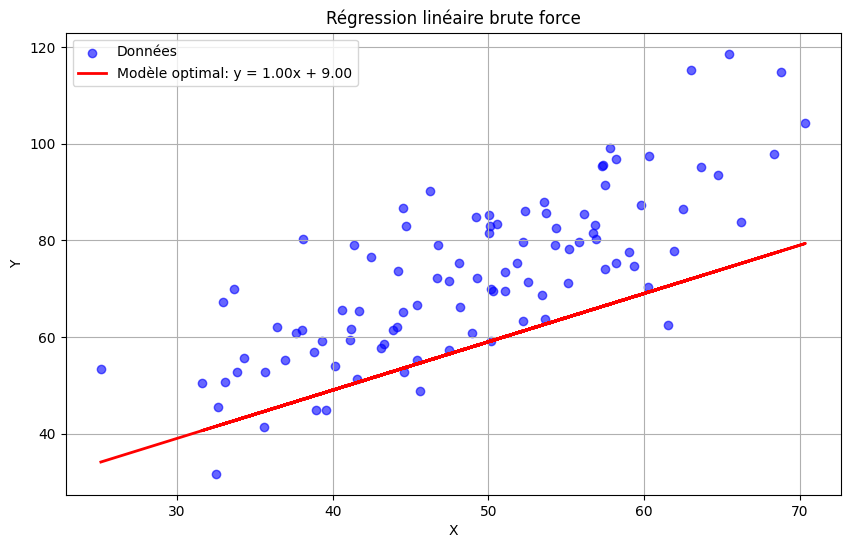

Programme terminé. Le meilleur modèle a été trouvé et affiché.


In [ ]:
# Tracé des données et du modèle optimal
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label='Données', color='blue', alpha=0.6)
plt.plot(X, best_m * X + best_b, color='red', linewidth=2, label=f'Modèle optimal: y = {best_m:.2f}x + {best_b:.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Régression linéaire brute force')
plt.legend()
plt.grid()
plt.show()

# Message de fin
print("Programme terminé. Le meilleur modèle a été trouvé et affiché.")


**4. Quelles sont les limites de cette approche ?**
L'approche Brute Force a plusieurs inconvénients majeurs :

**1. Temps de calcul extrêmement long **




Tester 20 millions de modèles est inefficace.
Si chaque évaluation prend 1 milliseconde, il faudrait 5h30 pour explorer toutes les combinaisons !

**2. Consommation de mémoire **

Chaque évaluation nécessite de stocker les données en mémoire.
Peut devenir impossible pour de grands ensembles de données.


**3. Résolution limitée **

Une précision de
10-²
  pour
𝑚
m et
𝑏
b peut ne pas être suffisante.
On pourrait avoir besoin d’une résolution plus fine, mais cela multiplierait encore le nombre de modèles.

**4. Aucune optimisation intelligente **

On teste toutes les combinaisons sans tirer de conclusions des erreurs précédentes.
La descente de gradient est une approche beaucoup plus efficace.

# **Descente de gradient**

## **Introduction**
La **descente de gradient** est une technique utilisée pour **trouver le minimum d’une fonction**, en particulier pour **minimiser l’erreur d’un modèle**. Elle est couramment utilisée en **apprentissage automatique** et en **régression linéaire**.

L’idée est simple :
1. **Regarder la pente de la fonction d’erreur** (sa dérivée).
2. **Avancer progressivement** dans la direction qui **diminue l’erreur**.
3. **S’arrêter lorsque la pente est nulle** (on atteint le minimum).

Dans notre cas, nous voulons **minimiser l’erreur du modèle** en ajustant **m** et **b**.


## **Calcul des dérivées partielles de l’erreur**
Nous utilisons **l’erreur quadratique moyenne (MSE)** comme fonction d’erreur :

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (Y_i - (m X_i + b))^2
$$

Pour appliquer la descente de gradient, nous devons **calculer les dérivées partielles** de cette erreur **par rapport à \( m \) et \( b \)** :

- **Dérivée par rapport à \( m \) :**
  $$ \frac{\partial MSE}{\partial m} = -\frac{2}{n} \sum_{i=1}^{n} X_i (Y_i - (m X_i + b)) $$

- **Dérivée par rapport à \( b \) :**
  $$ \frac{\partial MSE}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (Y_i - (m X_i + b)) $$

Ces dérivées nous indiquent **dans quelle direction ajuster \( m \) et \( b \) pour réduire l’erreur**.



## Implémentation de la Descente de Gradient

In [ ]:

import numpy as np

def gradient_descent(X, Y, lr=0.0001, epochs=1000):
    m, b = 0, 0  # Initialisation
    n = len(X)

    mse_history = []  # Pour stocker les erreurs

    for _ in range(epochs):
        Y_pred = m * X + b
        dm = (-2/n) * np.sum(X * (Y - Y_pred))
        db = (-2/n) * np.sum(Y - Y_pred)
        m -= lr * dm
        b -= lr * db
        mse_history.append(mse(m, b, X, Y))

    return m, b, mse_history

# Assuming 'mse' function and X, Y are defined from previous code

# Exécution de la descente de gradient with adjusted learning rate
m_opt, b_opt, mse_history = gradient_descent(X, Y, lr=0.0001, epochs=1000)
print(f'Modèle optimal (Descente de Gradient) : m = {m_opt}, b = {b_opt}')


Modèle optimal (Descente de Gradient) : m = 1.4777440851894448, b = 0.08893651993741351


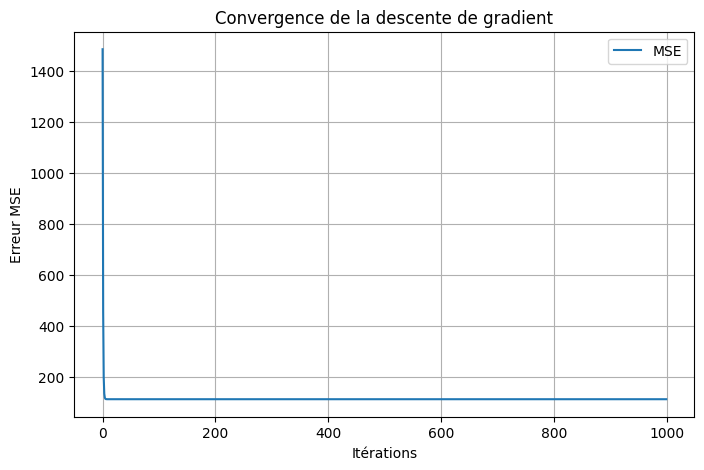

In [ ]:
# Visualisation de la convergence de la MSE
plt.figure(figsize=(8,5))
plt.plot(mse_history, label='MSE')
plt.xlabel('Itérations')
plt.ylabel('Erreur MSE')
plt.title('Convergence de la descente de gradient')
plt.legend()
plt.grid()
plt.show()

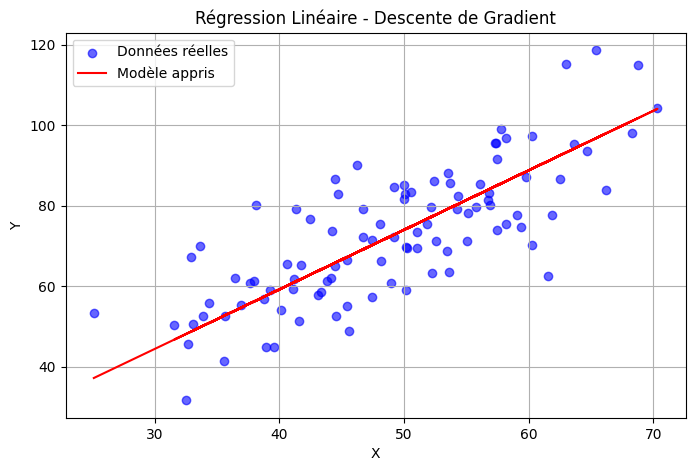

In [ ]:
# Visualisation du modèle appris
plt.figure(figsize=(8,5))
plt.scatter(X, Y, color='blue', alpha=0.6, label='Données réelles')
plt.plot(X, m_opt * X + b_opt, color='red', label='Modèle appris')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Régression Linéaire - Descente de Gradient')
plt.legend()
plt.grid()
plt.show()

## **Pourquoi plusieurs itérations sont nécessaires ?**
La descente de gradient fonctionne par **ajustements successifs** des paramètres. Une seule mise à jour améliore légèrement la précision, mais **ce n'est pas suffisant pour obtenir une droite bien ajustée aux données**.

Nous devons **répéter cette mise à jour** plusieurs fois, en partant toujours des paramètres précédemment calculés, pour **approcher progressivement la meilleure droite**.


## **Prochaine étape : boucle d’itérations**
Pour que la descente de gradient soit efficace, on ne peut pas s'arrêter après une seule mise à jour. On doit **répéter le processus sur plusieurs milliers d'itérations** pour que les paramètres \( m \) et \( b \) convergent vers des valeurs optimales.

### **Stratégie utilisée**
- Nous normalisons \( X \) avant de commencer la descente de gradient. Cela permet d'éviter des mises à jour trop brutales et d'améliorer la stabilité de l'apprentissage.
- Ensuite, nous faisons une **mise à jour successive des paramètres** en répétant le calcul des gradients et l'ajustement de \( m \) et \( b \) sur plusieurs itérations.
- Pour s'assurer que l'apprentissage est bien **progressif et cohérent**, nous stockons les valeurs de \( m \) et \( b \) à chaque itération afin d'observer leur évolution.
- Enfin, nous appliquons une **dé-normalisation** des paramètres pour retrouver une droite utilisable sur les données d'origine.

### **Pourquoi cette approche fonctionne bien ?**
- La normalisation stabilise l'apprentissage.
- Le suivi des itérations assure une convergence progressive.
- On ne repart **jamais de zéro**, chaque mise à jour s'appuie sur la précédente.





Nouvelle valeur finale de m : 3.5477
Nouvelle valeur finale de b : -2.0117


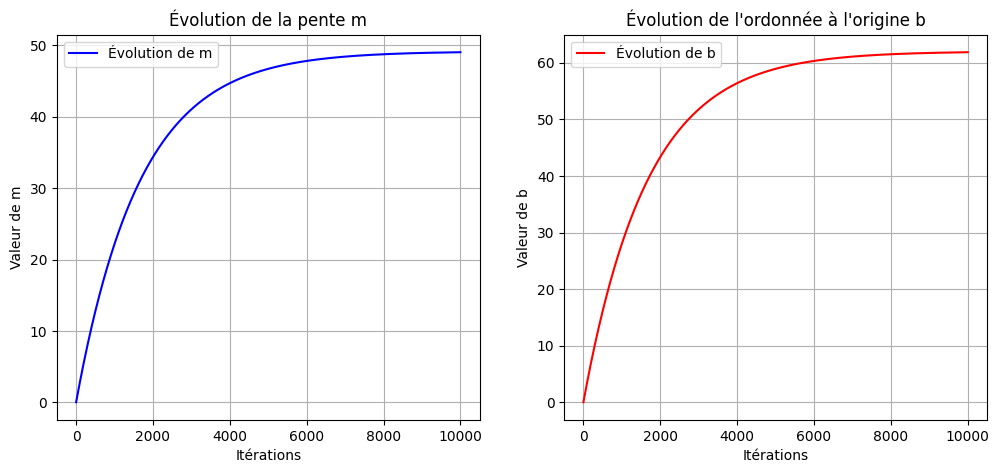

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Normalisation de X (mais pas de Y !)
def normalize_data(X):
    """ Normalise X pour éviter des mises à jour trop brutales. """
    X_mean, X_std = np.mean(X), np.std(X)
    X_norm = (X - X_mean) / X_std
    return X_norm, X_mean, X_std

# Fonction de mise à jour des paramètres avec descente de gradient stabilisée
def update_parameters(m, b, X, Y, learning_rate, num_iterations):
    """
    Met à jour les paramètres m et b en utilisant la descente de gradient avec normalisation de X.

    Paramètres :
    - m : valeur initiale de la pente
    - b : valeur initiale de l'ordonnée à l'origine
    - X : valeurs normalisées de X
    - Y : valeurs originales de Y (pas normalisées)
    - learning_rate : taux d'apprentissage
    - num_iterations : nombre d'itérations de mise à jour

    Retourne :
    - m_final : valeur finale de la pente
    - b_final : valeur finale de l'ordonnée à l'origine
    - historique_m, historique_b : évolution des paramètres au fil des itérations
    """
    n = len(X)
    historique_m, historique_b = [], []

    for i in range(num_iterations):
        # Calcul des gradients
        gradient_m = (-2/n) * np.sum(X * (Y - (m * X + b)))
        gradient_b = (-2/n) * np.sum(Y - (m * X + b))

        # Mise à jour des paramètres
        m -= learning_rate * gradient_m
        b -= learning_rate * gradient_b

        # Sauvegarde de l'évolution des paramètres
        historique_m.append(m)
        historique_b.append(b)

    return m, b, historique_m, historique_b

# **Test avec normalisation de X uniquement**
X_test = np.array([3, 7, 15, 23, 42])
Y_test = np.array([10, 25, 50, 75, 150])

# Normalisation de X uniquement
X_norm, X_mean, X_std = normalize_data(X_test)

# Initialisation des paramètres (on peut les modifier)
m_init, b_init = 0, 0
learning_rate = 0.0003  # Apprentissage équilibré
num_iterations = 10000  # Assez d'itérations pour assurer convergence

# Exécution de la descente de gradient
m_final, b_final, historique_m, historique_b = update_parameters(m_init, b_init, X_norm, Y_test, learning_rate, num_iterations)

# **Dé-normalisation finale de m et ajustement de b**
m_final = m_final / X_std  # Ajustement de m pour revenir à l'échelle d'origine
b_final = b_final - (m_final * X_mean)  # Ajustement final de b

# **Affichage des résultats**
print(f"Nouvelle valeur finale de m : {m_final:.4f}")
print(f"Nouvelle valeur finale de b : {b_final:.4f}")

# **Affichage de l'évolution des paramètres**
plt.figure(figsize=(12, 5))

# Courbe de m
plt.subplot(1, 2, 1)
plt.plot(historique_m, label="Évolution de m", color='blue')
plt.xlabel("Itérations")
plt.ylabel("Valeur de m")
plt.title("Évolution de la pente m")
plt.legend()
plt.grid()

# Courbe de b
plt.subplot(1, 2, 2)
plt.plot(historique_b, label="Évolution de b", color='red')
plt.xlabel("Itérations")
plt.ylabel("Valeur de b")
plt.title("Évolution de l'ordonnée à l'origine b")
plt.legend()
plt.grid()

plt.show()


**3.4 Conclusion sur la descente de gradient**
**Avantages :**

- La descente de gradient permet de trouver le minimum global (pour une fonction convexe comme le MSE) de manière efficace sans avoir à tester toutes les combinaisons possibles.

- Elle est itérative et s’adapte bien même en cas d’augmentation du nombre de paramètres (régression multiple ou modèles non linéaires).

- Elle permet de partir de valeurs initiales arbitraires et de converger vers la solution optimale en suivant la pente négative.

**Points à surveiller :**

- Le choix du taux d’apprentissage est crucial : un taux trop élevé peut faire diverger l’algorithme, alors qu’un taux trop faible ralentit la convergence.
- Le nombre d’itérations et le critère d’arrêt (par exemple, lorsque la variation de l’erreur devient négligeable) doivent être définis pour garantir une convergence correcte sans surcoût de calcul.
En résumé, la descente de gradient s’avère être une méthode robuste et efficace pour ajuster les paramètres d’un modèle de régression linéaire, surpassant largement l’approche brute force en termes de temps de calcul et d’extensibilité.

**Conclusion :**

L'approche Brute Force fonctionne théoriquement, mais elle est impraticable en raison du nombre énorme de modèles possibles. La descente de gradient est une méthode bien plus efficace pour trouver les meilleurs paramètres
𝑚
m et
𝑏
b sans tester toutes les combinaisons